<a href="https://colab.research.google.com/github/chris1982-arch/Lab2_Deep-Learning/blob/main/task1_vanilla_gan/task1_vanilla_gan.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1 — Vanilla GAN

This notebook implements a vanilla Generative Adversarial Network (Goodfellow et al., 2014) trained on MNIST.

**Reference:** Goodfellow, I., Pouget-Abadie, J., Mirza, M., et al. (2014). *Generative Adversarial Nets*. NeurIPS. [arXiv:1406.2661](https://arxiv.org/abs/1406.2661)

**Run on Colab:** [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chris1982-arch/Lab2_Deep-Learning/blob/main/task1_vanilla_gan/task1_vanilla_gan.ipynb)

---

## Theory recap

A GAN is a two-player minimax game between:
- **Generator** $G$: maps noise $z \sim p_z$ to fake samples $G(z)$
- **Discriminator** $D$: outputs the probability that a sample is real

The value function is:

$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

At the global optimum, $p_g = p_{data}$ and $D(x) = 1/2$ everywhere (Theorem 1 of the paper).

**Non-saturating trick (Section 3):** instead of minimizing $\log(1 - D(G(z)))$, we train $G$ to *maximize* $\log D(G(z))$ — same fixed point, much stronger gradients early in training.

In [ ]:
# Install wandb if on Colab (skip if already installed)
!pip install wandb -q

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tqdm
import wandb

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


## Hyperparameters

- `Z_dim = 100` — standard latent dimension for MNIST (used in the Goodfellow paper)
- `lr = 2e-4` with Adam `beta1 = 0.5` — de facto GAN choice since DCGAN (Radford et al., 2015)
- Batch size 128 for stable gradient estimates

In [ ]:
mb_size = 128
Z_dim   = 100
X_dim   = 784       # 28 x 28 flattened
lr      = 2e-4
beta1   = 0.5
epochs  = 100

## Data

MNIST images are normalized to $[-1, 1]$ to match the `Tanh` output of the generator.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.Lambda(lambda x: x.view(-1))
])

train_dataset = datasets.MNIST(root='./MNIST', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=mb_size, shuffle=True, num_workers=2, drop_last=True)

print(f"Training set size: {len(train_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")

Training set size: 60000
Batches per epoch: 468


## Generator

4-layer MLP: `z(100) → 256 → 512 → 1024 → x(784)`.
`LeakyReLU(0.2)` activations for better gradient flow, `Tanh` output.

In [ ]:
def xavier_init(m):
    """Xavier normal init — mentioned in the original tutorial code."""
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)


class Generator(nn.Module):
    """
    G: z (noise) -> x (fake image).
    The paper uses a mixture of ReLU+sigmoid; modern practice uses
    LeakyReLU+Tanh which converges faster on MNIST.
    """
    def __init__(self, z_dim=Z_dim, x_dim=X_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, x_dim),
            nn.Tanh()                          # output in [-1, 1]
        )
        self.apply(xavier_init)

    def forward(self, z):
        return self.net(z)

## Discriminator

4-layer MLP: `x(784) → 1024 → 512 → 256 → 1 (logit)`.
`Dropout(0.3)` is added as mentioned in Section 5 of the paper.
D outputs logits (no sigmoid) — the sigmoid is applied inside
`BCEWithLogitsLoss` for numerical stability.

In [ ]:
class Discriminator(nn.Module):
    """
    D: x -> scalar logit. High logit => likely real.
    """
    def __init__(self, x_dim=X_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(x_dim, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1)                  # logits, no sigmoid
        )
        self.apply(xavier_init)

    def forward(self, x):
        return self.net(x)

## Training loop

Following **Algorithm 1** of the paper with `k=1`: alternate one D step with one G step.

Key implementation details:
- **D step:** maximize `log D(x) + log(1 - D(G(z)))` — BCE loss with real=0.9, fake=0.0
- **G step (non-saturating):** maximize `log D(G(z))` — i.e. `BCE(D(G(z)), 1)`
- **Label smoothing** (real = 0.9 instead of 1.0) prevents D from becoming overconfident
- **`G_sample.detach()`** in D step cuts gradient flow to G when training D

In [ ]:
def train_one_epoch(G, D, loss_fn, G_solver, D_solver, train_loader, epoch):
    G.train(); D.train()
    D_loss_real_total = D_loss_fake_total = G_loss_total = 0.0
    D_real_score = D_fake_score = 0.0

    pbar = tqdm.tqdm(train_loader, desc=f"Epoch {epoch}")
    for X_real, _ in pbar:
        X_real = X_real.to(device)
        bsz = X_real.size(0)

        # Label smoothing: real=0.9, fake=0.0
        real_label = torch.full((bsz, 1), 0.9, device=device)
        fake_label = torch.zeros((bsz, 1), device=device)

        # ---- Train Discriminator ----
        z = torch.randn(bsz, Z_dim, device=device)
        G_sample = G(z)
        D_real_logits = D(X_real)
        D_fake_logits = D(G_sample.detach())          # cut gradient to G
        D_loss_real = loss_fn(D_real_logits, real_label)
        D_loss_fake = loss_fn(D_fake_logits, fake_label)
        D_loss = D_loss_real + D_loss_fake

        D_solver.zero_grad()
        D_loss.backward()
        D_solver.step()

        # ---- Train Generator (non-saturating) ----
        z = torch.randn(bsz, Z_dim, device=device)
        G_sample = G(z)
        D_fake_logits = D(G_sample)
        G_loss = loss_fn(D_fake_logits, torch.ones((bsz, 1), device=device))

        G_solver.zero_grad()
        G_loss.backward()
        G_solver.step()

        # ---- Bookkeeping ----
        D_loss_real_total += D_loss_real.item()
        D_loss_fake_total += D_loss_fake.item()
        G_loss_total      += G_loss.item()
        D_real_score      += torch.sigmoid(D_real_logits).mean().item()
        D_fake_score      += torch.sigmoid(D_fake_logits).mean().item()

        pbar.set_postfix(D_loss=f"{D_loss.item():.3f}",
                         G_loss=f"{G_loss.item():.3f}")

    n = len(train_loader)
    return {
        "D_loss_real": D_loss_real_total / n,
        "D_loss_fake": D_loss_fake_total / n,
        "D_loss":      (D_loss_real_total + D_loss_fake_total) / n,
        "G_loss":      G_loss_total / n,
        "D(x)":        D_real_score / n,              # should drift toward 0.5
        "D(G(z))":     D_fake_score / n,              # should drift toward 0.5
    }

## Sample visualization

In [ ]:
def show_samples(G, epoch, n=16):
    """Generate and display a 4x4 grid of samples. Also saves to disk."""
    G.eval()
    with torch.no_grad():
        z = torch.randn(n, Z_dim, device=device)
        samples = G(z).cpu().numpy()
    samples = (samples + 1) / 2  # [-1,1] -> [0,1] for display

    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)
    for i, s in enumerate(samples):
        ax = plt.subplot(gs[i])
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_aspect('equal')
        plt.imshow(s.reshape(28, 28), cmap='Greys_r')

    os.makedirs("results/samples", exist_ok=True)
    path = f"results/samples/epoch_{str(epoch).zfill(3)}.png"
    plt.savefig(path, bbox_inches='tight')
    plt.show()
    return path

In [ ]:
!wandb login --relogin

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


In [ ]:
!wandb online

W&B online. Running your script from this directory will now sync to the cloud.


## Run training

Set `USE_WANDB = False` if you don't want to use wandb logging.

Training 100 epochs on a Colab T4 GPU takes ~25-35 minutes.

D(G(z)),█▂▁▂
D(x),█▂▃▁
D_loss,█▃▁▃
D_loss_fake,█▂▁▁
D_loss_real,▁▇▇█
G_loss,▁▆█▇
epoch,▁▃▆█
D(G(z)),0.19721
D(x),0.66712
D_loss,0.94634
D_loss_fake,0.32097


Epoch 0: 100%|██████████| 468/468 [00:16<00:00, 28.13it/s, D_loss=0.927, G_loss=1.648]


[epoch 000] D_loss=1.0595  G_loss=1.3533  D(x)=0.715  D(G(z))=0.292


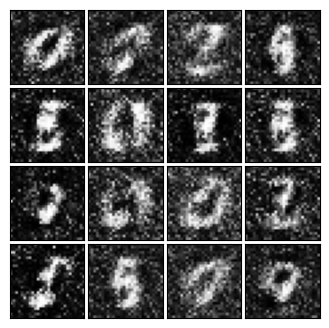

Epoch 1: 100%|██████████| 468/468 [00:18<00:00, 25.79it/s, D_loss=0.911, G_loss=1.943]


[epoch 001] D_loss=0.9504  G_loss=1.9532  D(x)=0.671  D(G(z))=0.186


Epoch 2: 100%|██████████| 468/468 [00:18<00:00, 25.05it/s, D_loss=0.949, G_loss=1.899]


[epoch 002] D_loss=0.9300  G_loss=2.0440  D(x)=0.675  D(G(z))=0.180


Epoch 3: 100%|██████████| 468/468 [00:17<00:00, 26.53it/s, D_loss=0.905, G_loss=2.349]


...

[epoch 008] D_loss=1.1440  G_loss=1.3270  D(x)=0.573  D(G(z))=0.312


Epoch 9: 100%|██████████| 468/468 [00:17<00:00, 26.62it/s, D_loss=1.323, G_loss=1.565]


[epoch 009] D_loss=1.1572  G_loss=1.2954  D(x)=0.567  D(G(z))=0.319


Epoch 10: 100%|██████████| 468/468 [00:16<00:00, 28.17it/s, D_loss=1.223, G_loss=1.106]


[epoch 010] D_loss=1.1826  G_loss=1.2331  D(x)=0.554  D(G(z))=0.331


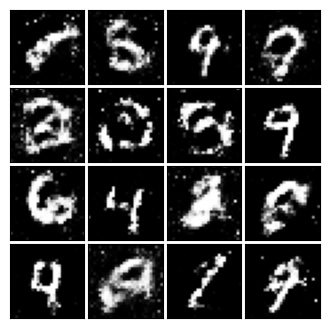

Epoch 11: 100%|██████████| 468/468 [00:17<00:00, 27.03it/s, D_loss=1.237, G_loss=1.097]


[epoch 011] D_loss=1.1960  G_loss=1.2044  D(x)=0.548  D(G(z))=0.338


Epoch 12: 100%|██████████| 468/468 [00:17<00:00, 27.14it/s, D_loss=1.118, G_loss=1.101]


[epoch 012] D_loss=1.2100  G_loss=1.1720  D(x)=0.541  D(G(z))=0.346


Epoch 13: 100%|██████████| 468/468 [00:17<00:00, 26.06it/s, D_loss=1.200, G_loss=1.087]


...

[epoch 018] D_loss=1.2533  G_loss=1.0773  D(x)=0.518  D(G(z))=0.370


Epoch 19: 100%|██████████| 468/468 [00:18<00:00, 25.63it/s, D_loss=1.258, G_loss=0.965]


[epoch 019] D_loss=1.2530  G_loss=1.0712  D(x)=0.518  D(G(z))=0.372


Epoch 20: 100%|██████████| 468/468 [00:17<00:00, 27.45it/s, D_loss=1.311, G_loss=1.116]


[epoch 020] D_loss=1.2561  G_loss=1.0689  D(x)=0.517  D(G(z))=0.373


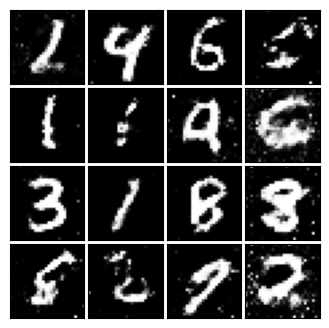

Epoch 21: 100%|██████████| 468/468 [00:19<00:00, 24.56it/s, D_loss=1.219, G_loss=1.097]


[epoch 021] D_loss=1.2584  G_loss=1.0685  D(x)=0.515  D(G(z))=0.373


Epoch 22: 100%|██████████| 468/468 [00:18<00:00, 24.79it/s, D_loss=1.239, G_loss=0.959]


[epoch 022] D_loss=1.2594  G_loss=1.0632  D(x)=0.515  D(G(z))=0.374


Epoch 23: 100%|██████████| 468/468 [00:20<00:00, 23.31it/s, D_loss=1.275, G_loss=0.983]


...

[epoch 028] D_loss=1.2680  G_loss=1.0464  D(x)=0.510  D(G(z))=0.378


Epoch 29: 100%|██████████| 468/468 [00:17<00:00, 26.29it/s, D_loss=1.313, G_loss=1.100]


[epoch 029] D_loss=1.2687  G_loss=1.0429  D(x)=0.509  D(G(z))=0.379


Epoch 30: 100%|██████████| 468/468 [00:17<00:00, 26.28it/s, D_loss=1.305, G_loss=1.088]


[epoch 030] D_loss=1.2685  G_loss=1.0453  D(x)=0.509  D(G(z))=0.378


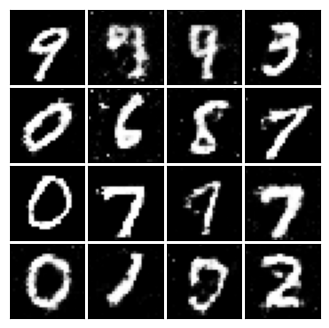

Epoch 31: 100%|██████████| 468/468 [00:18<00:00, 25.43it/s, D_loss=1.344, G_loss=1.017]


[epoch 031] D_loss=1.2685  G_loss=1.0416  D(x)=0.509  D(G(z))=0.379


Epoch 32: 100%|██████████| 468/468 [00:19<00:00, 24.58it/s, D_loss=1.259, G_loss=1.086]


[epoch 032] D_loss=1.2701  G_loss=1.0388  D(x)=0.509  D(G(z))=0.381


Epoch 33: 100%|██████████| 468/468 [00:18<00:00, 25.36it/s, D_loss=1.278, G_loss=1.077]


...

[epoch 038] D_loss=1.2769  G_loss=1.0155  D(x)=0.505  D(G(z))=0.387


Epoch 39: 100%|██████████| 468/468 [00:18<00:00, 25.80it/s, D_loss=1.278, G_loss=0.910]


[epoch 039] D_loss=1.2770  G_loss=1.0216  D(x)=0.504  D(G(z))=0.385


Epoch 40: 100%|██████████| 468/468 [00:18<00:00, 26.00it/s, D_loss=1.299, G_loss=1.120]


[epoch 040] D_loss=1.2752  G_loss=1.0215  D(x)=0.505  D(G(z))=0.386


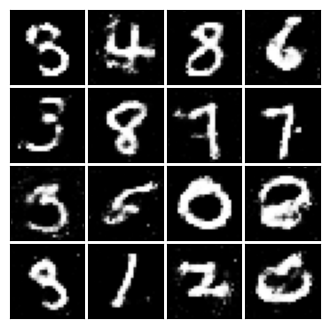

Epoch 41: 100%|██████████| 468/468 [00:19<00:00, 24.10it/s, D_loss=1.254, G_loss=1.231]


[epoch 041] D_loss=1.2756  G_loss=1.0195  D(x)=0.505  D(G(z))=0.387


Epoch 42: 100%|██████████| 468/468 [00:18<00:00, 24.72it/s, D_loss=1.263, G_loss=1.106]


[epoch 042] D_loss=1.2786  G_loss=1.0116  D(x)=0.504  D(G(z))=0.388


Epoch 43: 100%|██████████| 468/468 [00:18<00:00, 25.39it/s, D_loss=1.306, G_loss=0.864]


...

[epoch 048] D_loss=1.2788  G_loss=1.0159  D(x)=0.503  D(G(z))=0.387


Epoch 49: 100%|██████████| 468/468 [00:18<00:00, 25.72it/s, D_loss=1.318, G_loss=0.922]


[epoch 049] D_loss=1.2787  G_loss=1.0119  D(x)=0.503  D(G(z))=0.389


Epoch 50: 100%|██████████| 468/468 [00:19<00:00, 23.71it/s, D_loss=1.280, G_loss=0.919]


[epoch 050] D_loss=1.2801  G_loss=1.0090  D(x)=0.502  D(G(z))=0.390


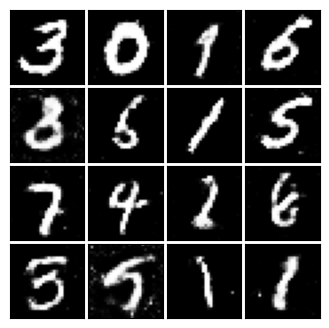

Epoch 51: 100%|██████████| 468/468 [00:20<00:00, 23.25it/s, D_loss=1.278, G_loss=0.939]


[epoch 051] D_loss=1.2790  G_loss=1.0140  D(x)=0.503  D(G(z))=0.388


Epoch 52: 100%|██████████| 468/468 [00:19<00:00, 24.44it/s, D_loss=1.323, G_loss=0.979]


[epoch 052] D_loss=1.2793  G_loss=1.0121  D(x)=0.503  D(G(z))=0.388


Epoch 53: 100%|██████████| 468/468 [00:18<00:00, 24.83it/s, D_loss=1.245, G_loss=1.095]


...

[epoch 058] D_loss=1.2807  G_loss=1.0062  D(x)=0.502  D(G(z))=0.390


Epoch 59: 100%|██████████| 468/468 [00:18<00:00, 24.73it/s, D_loss=1.261, G_loss=0.973]


[epoch 059] D_loss=1.2802  G_loss=1.0123  D(x)=0.502  D(G(z))=0.389


Epoch 60: 100%|██████████| 468/468 [00:19<00:00, 23.93it/s, D_loss=1.296, G_loss=0.948]


[epoch 060] D_loss=1.2772  G_loss=1.0110  D(x)=0.503  D(G(z))=0.389


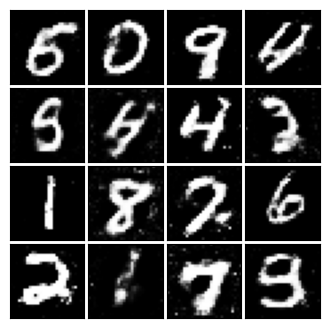

Epoch 61: 100%|██████████| 468/468 [00:18<00:00, 24.81it/s, D_loss=1.220, G_loss=1.027]


[epoch 061] D_loss=1.2804  G_loss=1.0111  D(x)=0.502  D(G(z))=0.389


Epoch 62: 100%|██████████| 468/468 [00:19<00:00, 24.51it/s, D_loss=1.254, G_loss=0.948]


[epoch 062] D_loss=1.2796  G_loss=1.0058  D(x)=0.502  D(G(z))=0.390


Epoch 63: 100%|██████████| 468/468 [00:18<00:00, 24.76it/s, D_loss=1.214, G_loss=0.910]


...

[epoch 068] D_loss=1.2793  G_loss=1.0097  D(x)=0.502  D(G(z))=0.389


Epoch 69: 100%|██████████| 468/468 [00:19<00:00, 23.91it/s, D_loss=1.314, G_loss=0.903]


[epoch 069] D_loss=1.2792  G_loss=1.0087  D(x)=0.503  D(G(z))=0.390


Epoch 70: 100%|██████████| 468/468 [00:19<00:00, 23.85it/s, D_loss=1.283, G_loss=0.874]


[epoch 070] D_loss=1.2785  G_loss=1.0076  D(x)=0.503  D(G(z))=0.390


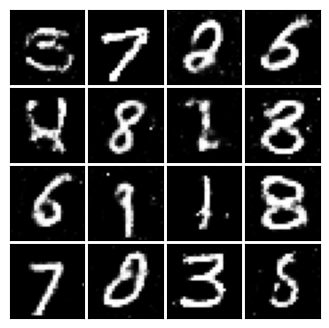

Epoch 71: 100%|██████████| 468/468 [00:19<00:00, 24.20it/s, D_loss=1.207, G_loss=1.095]


[epoch 071] D_loss=1.2765  G_loss=1.0162  D(x)=0.504  D(G(z))=0.388


Epoch 72: 100%|██████████| 468/468 [00:19<00:00, 24.21it/s, D_loss=1.302, G_loss=0.943]


[epoch 072] D_loss=1.2779  G_loss=1.0109  D(x)=0.503  D(G(z))=0.389


Epoch 73: 100%|██████████| 468/468 [00:19<00:00, 23.58it/s, D_loss=1.315, G_loss=1.018]


...

[epoch 078] D_loss=1.2779  G_loss=1.0155  D(x)=0.503  D(G(z))=0.388


Epoch 79: 100%|██████████| 468/468 [00:20<00:00, 22.96it/s, D_loss=1.260, G_loss=1.021]


[epoch 079] D_loss=1.2777  G_loss=1.0050  D(x)=0.503  D(G(z))=0.391


Epoch 80: 100%|██████████| 468/468 [00:19<00:00, 23.95it/s, D_loss=1.245, G_loss=0.928]


[epoch 080] D_loss=1.2767  G_loss=1.0116  D(x)=0.503  D(G(z))=0.389


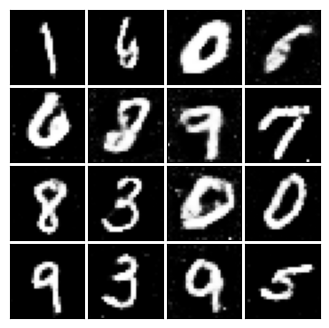

Epoch 81: 100%|██████████| 468/468 [00:21<00:00, 21.76it/s, D_loss=1.283, G_loss=1.024]


[epoch 081] D_loss=1.2769  G_loss=1.0146  D(x)=0.503  D(G(z))=0.388


Epoch 82: 100%|██████████| 468/468 [00:20<00:00, 22.68it/s, D_loss=1.232, G_loss=1.027]


[epoch 082] D_loss=1.2771  G_loss=1.0103  D(x)=0.504  D(G(z))=0.389


Epoch 83: 100%|██████████| 468/468 [00:20<00:00, 22.94it/s, D_loss=1.268, G_loss=0.911]


...

[epoch 088] D_loss=1.2771  G_loss=1.0071  D(x)=0.503  D(G(z))=0.391


Epoch 89: 100%|██████████| 468/468 [00:19<00:00, 24.01it/s, D_loss=1.306, G_loss=0.915]


[epoch 089] D_loss=1.2770  G_loss=1.0131  D(x)=0.503  D(G(z))=0.389


Epoch 90: 100%|██████████| 468/468 [00:19<00:00, 24.18it/s, D_loss=1.263, G_loss=0.861]


[epoch 090] D_loss=1.2741  G_loss=1.0150  D(x)=0.505  D(G(z))=0.389


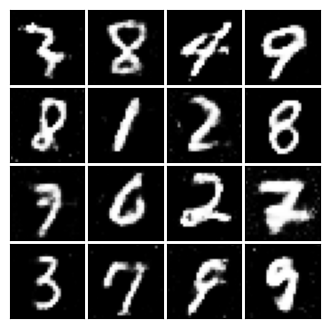

Epoch 91: 100%|██████████| 468/468 [00:20<00:00, 22.59it/s, D_loss=1.260, G_loss=0.945]


[epoch 091] D_loss=1.2734  G_loss=1.0152  D(x)=0.505  D(G(z))=0.388


Epoch 92: 100%|██████████| 468/468 [00:20<00:00, 23.10it/s, D_loss=1.311, G_loss=0.937]


[epoch 092] D_loss=1.2790  G_loss=1.0099  D(x)=0.502  D(G(z))=0.390


Epoch 93: 100%|██████████| 468/468 [00:19<00:00, 23.45it/s, D_loss=1.413, G_loss=0.974]


...

[epoch 097] D_loss=1.2733  G_loss=1.0118  D(x)=0.505  D(G(z))=0.389


Epoch 98: 100%|██████████| 468/468 [00:19<00:00, 23.60it/s, D_loss=1.229, G_loss=1.077]


[epoch 098] D_loss=1.2735  G_loss=1.0154  D(x)=0.505  D(G(z))=0.388


Epoch 99: 100%|██████████| 468/468 [00:20<00:00, 22.79it/s, D_loss=1.228, G_loss=0.972]


[epoch 099] D_loss=1.2731  G_loss=1.0136  D(x)=0.505  D(G(z))=0.389


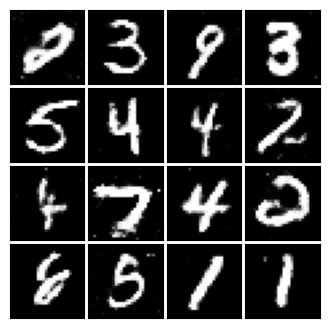

D(G(z)),▁▂▁▄▆▇▇▇████████████████████████████████
D(x),█▇▆▇▆▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
D_loss,▄▁▁▂▅▇▇▇▇███████████████████████████████
D_loss_fake,█▁▂▁▂▅▅▅▇▇▇▇▇▇▇█████████████████████████
D_loss_real,▁▄▄▆▇▇██████████████████████████████████
G_loss,██▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇█
D(G(z)),0.38884
D(x),0.50516
D_loss,1.2731
D_loss_fake,0.53332


In [ ]:
USE_WANDB = True          # Set to False to skip wandb

G = Generator().to(device)
D = Discriminator().to(device)

G_solver = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
D_solver = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))
loss_fn = nn.BCEWithLogitsLoss()

if USE_WANDB:
    wandb.init(project="vanilla-gan-mnist", config={
        "batch_size": mb_size, "Z_dim": Z_dim, "X_dim": X_dim,
        "lr": lr, "beta1": beta1, "epochs": epochs,
    })

history = {"D_loss": [], "G_loss": [], "D(x)": [], "D(G(z))": []}
best_g_loss = float('inf')
os.makedirs("checkpoints", exist_ok=True)

for epoch in range(epochs):
    metrics = train_one_epoch(G, D, loss_fn, G_solver, D_solver, train_loader, epoch)
    for k in history:
        history[k].append(metrics[k])
    print(f"[epoch {epoch:03d}] "
          f"D_loss={metrics['D_loss']:.4f}  "
          f"G_loss={metrics['G_loss']:.4f}  "
          f"D(x)={metrics['D(x)']:.3f}  "
          f"D(G(z))={metrics['D(G(z))']:.3f}")

    # Show samples every 10 epochs (to keep notebook clean)
    if epoch % 10 == 0 or epoch == epochs - 1:
        sample_path = show_samples(G, epoch)
        if USE_WANDB:
            wandb.log({**metrics, "samples": wandb.Image(sample_path), "epoch": epoch})
    elif USE_WANDB:
        wandb.log({**metrics, "epoch": epoch})

    if metrics["G_loss"] < best_g_loss:
        best_g_loss = metrics["G_loss"]
        torch.save(G.state_dict(), "checkpoints/G_best.pth")
        torch.save(D.state_dict(), "checkpoints/D_best.pth")

if USE_WANDB:
    wandb.finish()

## Training curves

- **Left:** D loss and G loss over time. Expect oscillation around a steady value, not smooth decrease — GANs are adversarial, not standard optimization.
- **Right:** `D(x)` and `D(G(z))` drift toward **0.5** as training progresses. This is the Nash equilibrium predicted by Theorem 1 of the paper — D cannot distinguish real from fake.

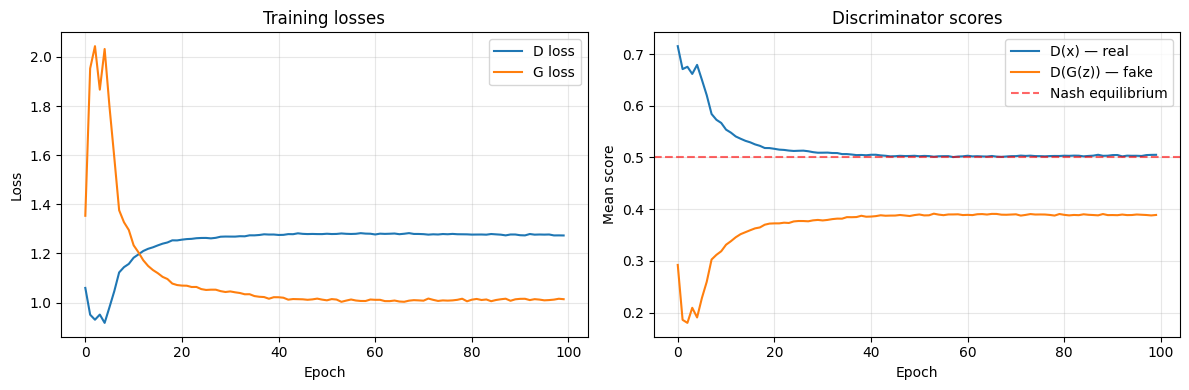

In [ ]:
os.makedirs("results", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["D_loss"], label="D loss")
axes[0].plot(history["G_loss"], label="G loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].set_title("Training losses")
axes[0].grid(alpha=0.3)

axes[1].plot(history["D(x)"], label="D(x) — real")
axes[1].plot(history["D(G(z))"], label="D(G(z)) — fake")
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.6, label="Nash equilibrium")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean score")
axes[1].legend()
axes[1].set_title("Discriminator scores")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results/training_curves.png", bbox_inches='tight', dpi=120)
plt.show()

## Final samples

Loading the best checkpoint and generating a final 4x4 grid.

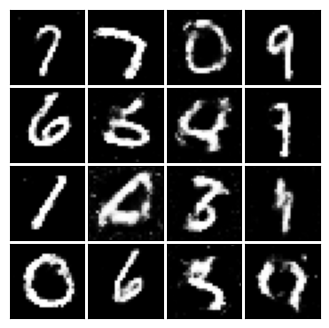

Final grid saved to: results/samples/epoch_final.png


In [ ]:
G.load_state_dict(torch.load("checkpoints/G_best.pth"))
final_path = show_samples(G, "final", n=16)
print(f"Final grid saved to: {final_path}")

In [ ]:
!wandb sync /content/wandb/offline-run-20260420_082204-ntxk4218

Find logs at: /content/wandb/debug-cli.root.log
Syncing: https://wandb.ai/chrispalandz-lule-university-of-technology/vanilla-gan-mnist/runs/ntxk4218 ... done.


## Conclusions

This notebook implements the vanilla GAN from Goodfellow et al. (2014) faithfully in its core (two-player minimax game, non-saturating G objective, alternating gradient updates), combined with post-2014 stability tricks from DCGAN (`LeakyReLU`, `Tanh` output, `Adam(beta1=0.5)`, label smoothing).

**Observations:**
- D(x) and D(G(z)) converge toward 0.5, indicating the equilibrium predicted by theory
- Generated samples become recognizable MNIST digits around epoch 20-30
- Losses oscillate rather than decrease monotonically — characteristic of adversarial training

**Next steps (Task 2):** replace BCE loss with logistic loss and compare results at 5, 10, and 50 epochs.